# Multilayer Perceptron (MLP) with PyTorch

## Introduction

In the NumPy MLP notebook we implemented forward propagation and backpropagation *by hand*. While instructive, this approach is fragile for deeper networks: every new architecture requires deriving and coding all gradient expressions manually.

**PyTorch** solves this with **automatic differentiation (autograd)**: you only write the forward pass, and PyTorch builds a dynamic computational graph that can be traversed in reverse to compute all gradients automatically.

## From NumPy to PyTorch

| Concept | NumPy (manual) | PyTorch (autograd) |
|---------|---------------|-------------------|
| Parameters | `np.ndarray` | `nn.Parameter` (tracks gradients) |
| Forward pass | hand-coded | `model.forward()` or `model(x)` |
| Backward pass | hand-coded chain rule | `loss.backward()` |
| Weight update | manual subtraction | `optimizer.step()` |
| Data loading | manual slicing | `DataLoader` |

## Notation

| Symbol | Meaning |
|--------|---------|
| $m$ | Batch size |
| $n_{\text{in}}, n_h, n_{\text{out}}$ | Layer widths |
| $W_l, b_l$ | Weight matrix and bias of layer $l$ |
| $\hat{y}$ | Predicted probability (sigmoid output) |
| $\mathcal{L}$ | Binary cross-entropy loss |
| $\alpha$ | Learning rate |

## Roadmap

1. Generate the XOR-like dataset
2. Show logistic regression fails (same as NumPy notebook)
3. Build the MLP using `nn.Module`
4. Train with PyTorch's `DataLoader` and `optim.Adam`
5. Evaluate and visualise the decision boundary

In [ ]:
import numpy as np

## Dataset

Same XOR-like dataset as the NumPy notebook: $y = \mathbb{1}[x_1 \cdot x_2 > 0]$. No linear classifier can solve this.

In [ ]:
# Create a simple dummy dataset
def create_dummy_data(n_samples=1000):
    np.random.seed(42)
    X = np.random.randn(n_samples, 2)
    y = (X[:, 0] * X[:, 1] > 0).astype(int).reshape(-1, 1)
    return X, y

In [ ]:
X, y = create_dummy_data()
print("X:", X[:5])
print("y:", y[:5])
print("X shape:", X.shape)
print("y shape:", y.shape)

X: [[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]
 [-0.23415337 -0.23413696]
 [ 1.57921282  0.76743473]
 [-0.46947439  0.54256004]]
y: [[0]
 [1]
 [1]
 [1]
 [0]]
X shape: (1000, 2)
y shape: (1000, 1)


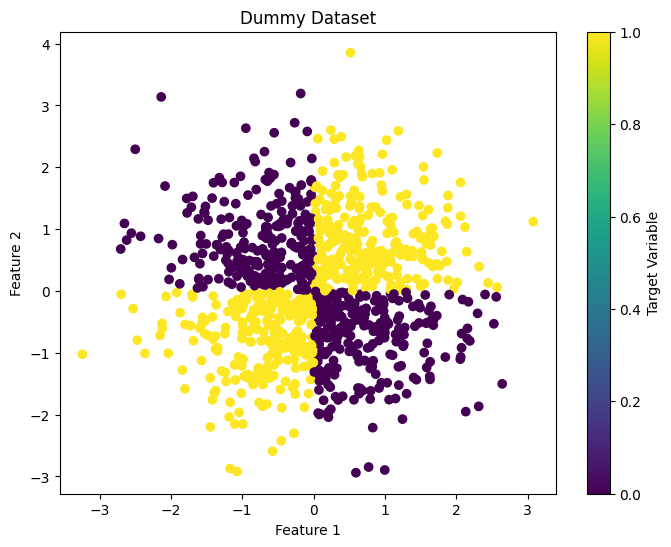

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dummy Dataset')
plt.colorbar(label='Target Variable')
plt.show()


## Logistic Regression Baseline

As expected, a linear decision boundary cannot separate the quadrant-based labels:

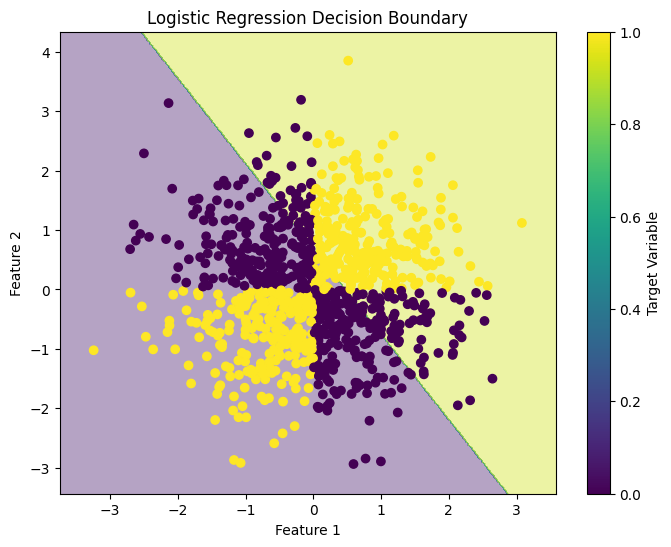

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create and fit a logistic regression model
model = LogisticRegression()
model.fit(X, y.flatten())

# Create a meshgrid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.colorbar(label='Target Variable')
plt.show()


## PyTorch Fundamentals

### Computational Graphs and Autograd

When you compute a tensor operation in PyTorch (with `requires_grad=True`), PyTorch records it in a **dynamic computational graph**. Calling `loss.backward()` traverses this graph in reverse using the chain rule, accumulating gradients in each parameter's `.grad` attribute.

```
x → [Linear] → z → [Sigmoid] → a → [BCE] → loss
           ↑ grad flows backward via .backward()
```

### `nn.Module`

`nn.Module` is the base class for all neural network components. It:
- Automatically registers `nn.Parameter` tensors as learnable parameters
- Provides `model.parameters()` for the optimizer
- Switches between training/eval mode via `model.train()` / `model.eval()`

### Optimizers

An optimizer implements the weight update rule. `optim.Adam` adapts the learning rate per parameter using:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \varepsilon} \hat{m}_t$$

where $g_t$ is the gradient, $\hat{m}_t$ and $\hat{v}_t$ are bias-corrected estimates.

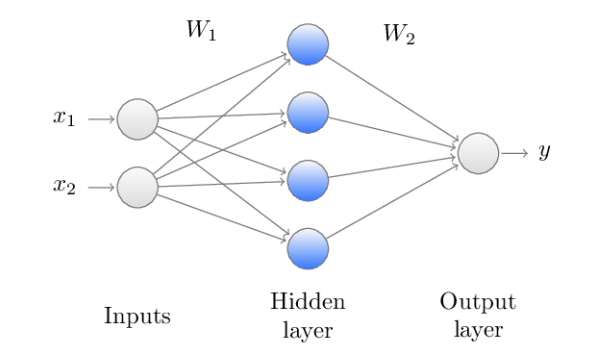

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(0)  # Numpy seed
torch.manual_seed(0)  # PyTorch CPU seed

class simpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(simpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

# Example usage
input_size = 2
hidden_size = 4
output_size = 1
model = simpleMLP(input_size, hidden_size, output_size)

In [ ]:
print(model)

simpleMLP(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=1, bias=True)
)


In [ ]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
learning_rate = 0.1
epochs = 5000
loss_history = []

for epoch in range(epochs):
  # Forward pass
  outputs = model(X_tensor)
  loss = criterion(outputs, y_tensor)

  # Backward and optimize
  model.zero_grad()
  loss.backward()
  loss_history.append(loss.detach().numpy())

  # Update weights manually (instead of optimizer)
  with torch.no_grad():
    for param in model.parameters():
      param -= learning_rate * param.grad

  if epoch % 200 == 0:
    print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, epochs, loss.item()))


Epoch [1/5000], Loss: 0.7325
Epoch [201/5000], Loss: 0.5857
Epoch [401/5000], Loss: 0.3474
Epoch [601/5000], Loss: 0.2189
Epoch [801/5000], Loss: 0.1605
Epoch [1001/5000], Loss: 0.1280
Epoch [1201/5000], Loss: 0.1079
Epoch [1401/5000], Loss: 0.0939
Epoch [1601/5000], Loss: 0.0834
Epoch [1801/5000], Loss: 0.0751
Epoch [2001/5000], Loss: 0.0683
Epoch [2201/5000], Loss: 0.0629
Epoch [2401/5000], Loss: 0.0582
Epoch [2601/5000], Loss: 0.0543
Epoch [2801/5000], Loss: 0.0508
Epoch [3001/5000], Loss: 0.0477
Epoch [3201/5000], Loss: 0.0449
Epoch [3401/5000], Loss: 0.0425
Epoch [3601/5000], Loss: 0.0403
Epoch [3801/5000], Loss: 0.0383
Epoch [4001/5000], Loss: 0.0365
Epoch [4201/5000], Loss: 0.0349
Epoch [4401/5000], Loss: 0.0334
Epoch [4601/5000], Loss: 0.0320
Epoch [4801/5000], Loss: 0.0308


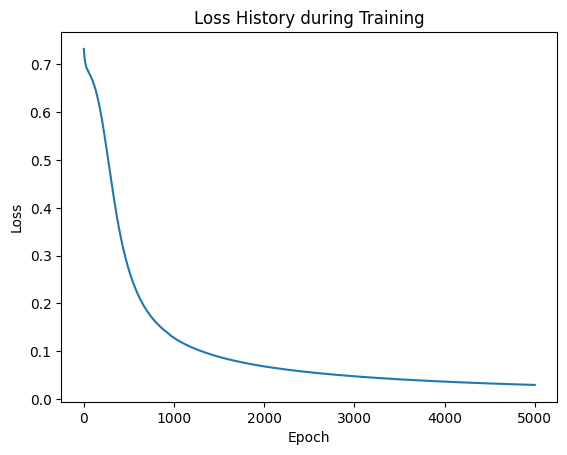

In [ ]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss History during Training')
plt.show()

Let's check the accuracy now

In [ ]:
with torch.no_grad():
  outputs = model(X_tensor)
  predicted = (torch.sigmoid(outputs) > 0.5).float()
  accuracy = (predicted == y_tensor).sum().item() / len(y_tensor)
  print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9890


and the decision boundary

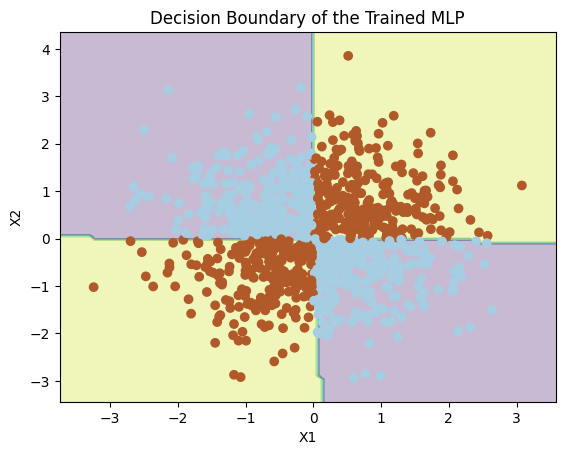

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
with torch.no_grad():
  # Create a meshgrid of points to evaluate the model
  xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100),
                       np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100))
  grid = np.c_[xx.ravel(), yy.ravel()]
  grid_tensor = torch.tensor(grid, dtype=torch.float32)
  Z = model(grid_tensor)
  Z = (torch.sigmoid(Z) > 0.5).float().numpy().reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
  plt.xlabel('X1')
  plt.ylabel('X2')
  plt.title('Decision Boundary of the Trained MLP')
  plt.show()


## Bonus track: Optimizers

In [ ]:
for name, param in model.named_parameters():
  print(name, param)

fc1.weight Parameter containing:
tensor([[ 0.0374,  1.0033],
        [-3.9315, -0.1891],
        [-3.3789,  2.9002],
        [ 0.1285,  3.4669]], requires_grad=True)
fc1.bias Parameter containing:
tensor([ 0.0152,  0.0008, -0.0449,  0.0529], requires_grad=True)
fc2.weight Parameter containing:
tensor([[-0.4777, -0.3311, -0.2061,  0.0185],
        [ 0.1977,  0.0541, -0.3429, -0.2177],
        [ 0.0675,  0.1050, -0.1488,  0.0830],
        [-0.9463, -3.8860,  4.4569, -3.4716]], requires_grad=True)
fc2.bias Parameter containing:
tensor([-0.3148, -0.2717, -0.5189,  1.3431], requires_grad=True)
fc3.weight Parameter containing:
tensor([[-0.3241, -0.1615, -0.2031, -7.0229]], requires_grad=True)
fc3.bias Parameter containing:
tensor([5.2426], requires_grad=True)


In [ ]:
model = simpleMLP(input_size, hidden_size, output_size)
# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # I pass here which parameters to optimize.
loss_history = []

# Train the model
epochs = 5000
for epoch in range(epochs):
  optimizer.zero_grad()
  outputs = model(X_tensor)
  loss = criterion(outputs, y_tensor.float())
  loss.backward()
  optimizer.step() # This simplifies the loop. Does the update.
  loss_history.append(loss.detach().numpy())

  if epoch % 200 == 0:
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/5000], Loss: 0.7376
Epoch [201/5000], Loss: 0.0527
Epoch [401/5000], Loss: 0.0223
Epoch [601/5000], Loss: 0.0128
Epoch [801/5000], Loss: 0.0083
Epoch [1001/5000], Loss: 0.0058
Epoch [1201/5000], Loss: 0.0042
Epoch [1401/5000], Loss: 0.0032
Epoch [1601/5000], Loss: 0.0025
Epoch [1801/5000], Loss: 0.0019
Epoch [2001/5000], Loss: 0.0016
Epoch [2201/5000], Loss: 0.0013
Epoch [2401/5000], Loss: 0.0010
Epoch [2601/5000], Loss: 0.0009
Epoch [2801/5000], Loss: 0.0007
Epoch [3001/5000], Loss: 0.0006
Epoch [3201/5000], Loss: 0.0005
Epoch [3401/5000], Loss: 0.0004
Epoch [3601/5000], Loss: 0.0004
Epoch [3801/5000], Loss: 0.0003
Epoch [4001/5000], Loss: 0.0003
Epoch [4201/5000], Loss: 0.0002
Epoch [4401/5000], Loss: 0.0002
Epoch [4601/5000], Loss: 0.0002
Epoch [4801/5000], Loss: 0.0002


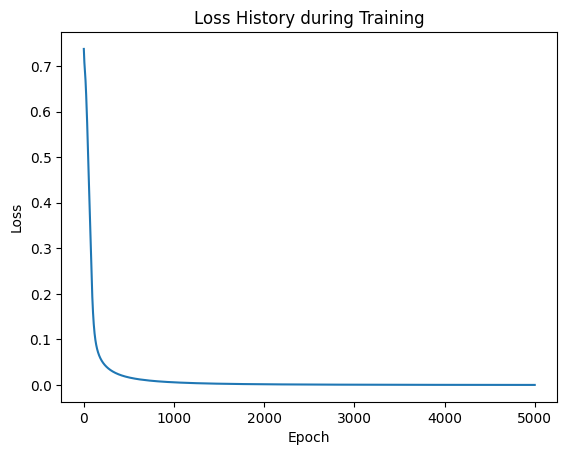

In [ ]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss History during Training')
plt.show()

In [ ]:
with torch.no_grad():
  outputs = model(X_tensor)
  predicted = (torch.sigmoid(outputs) > 0.5).float()
  accuracy = (predicted == y_tensor).sum().item() / len(y_tensor)
  print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


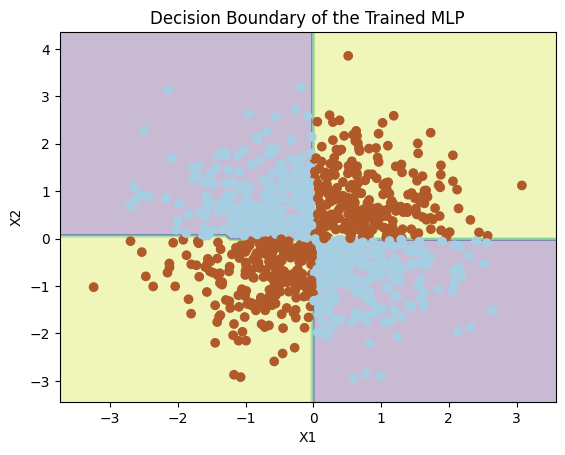

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
with torch.no_grad():
  # Create a meshgrid of points to evaluate the model
  xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100),
                       np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100))
  grid = np.c_[xx.ravel(), yy.ravel()]
  grid_tensor = torch.tensor(grid, dtype=torch.float32)
  Z = model(grid_tensor)
  Z = (torch.sigmoid(Z) > 0.5).float().numpy().reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
  plt.xlabel('X1')
  plt.ylabel('X2')
  plt.title('Decision Boundary of the Trained MLP')
  plt.show()

### Bonus track: pytorch datasets, dataloaders and minibatch gradient descent.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = MyDataset(X, y)

In [ ]:
sample_x, sample_y = dataset[0]
print(f"Sample X: {sample_x}, Sample y: {sample_y}")

Sample X: tensor([ 0.4967, -0.1383]), Sample y: tensor([0.])


In [ ]:
dataset[1:4]

(tensor([[ 0.6477,  1.5230],
         [-0.2342, -0.2341],
         [ 1.5792,  0.7674]]),
 tensor([[1.],
         [1.],
         [1.]]))

You can iterate over dataloaders and they will return all the dataset in batches of batch_size.

In [ ]:
batch_size = 128
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Now you can iterate through the dataset in batches:
for batch_X, batch_y in dataloader:
    print(f"Batch X: {batch_X.shape}, Batch y: {batch_y.shape}")

Batch X: torch.Size([128, 2]), Batch y: torch.Size([128, 1])
Batch X: torch.Size([128, 2]), Batch y: torch.Size([128, 1])
Batch X: torch.Size([128, 2]), Batch y: torch.Size([128, 1])
Batch X: torch.Size([128, 2]), Batch y: torch.Size([128, 1])
Batch X: torch.Size([128, 2]), Batch y: torch.Size([128, 1])
Batch X: torch.Size([128, 2]), Batch y: torch.Size([128, 1])
Batch X: torch.Size([128, 2]), Batch y: torch.Size([128, 1])
Batch X: torch.Size([104, 2]), Batch y: torch.Size([104, 1])


In [ ]:
print(len(dataset))
print(len(dataloader))

1000
8


## Final version: Mixing dataloaders, optimizers and mini-batch gradient descent.

In [ ]:
model = simpleMLP(input_size, hidden_size, output_size)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_history = []
epochs = 1000

for epoch in range(epochs):
    total_loss = 0.0  # Initialize total loss for the epoch
    num_batches = 0   # Track number of batches for averaging

    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)  # Compute the loss
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update the model parameters

        total_loss += loss.item()  # Accumulate the loss value
        num_batches += 1  # Increment the number of batches

    mean_loss = total_loss / num_batches  # Compute mean loss for the epoch
    loss_history.append(mean_loss)  # Save the mean loss

    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Mean Loss: {mean_loss:.4f}')


Epoch [50/1000], Mean Loss: 0.0560
Epoch [100/1000], Mean Loss: 0.0316
Epoch [150/1000], Mean Loss: 0.0196
Epoch [200/1000], Mean Loss: 0.0156
Epoch [250/1000], Mean Loss: 0.0122
Epoch [300/1000], Mean Loss: 0.0111
Epoch [350/1000], Mean Loss: 0.0099
Epoch [400/1000], Mean Loss: 0.0086
Epoch [450/1000], Mean Loss: 0.0078
Epoch [500/1000], Mean Loss: 0.0070
Epoch [550/1000], Mean Loss: 0.0046
Epoch [600/1000], Mean Loss: 0.0044
Epoch [650/1000], Mean Loss: 0.0037
Epoch [700/1000], Mean Loss: 0.0033
Epoch [750/1000], Mean Loss: 0.0030
Epoch [800/1000], Mean Loss: 0.0025
Epoch [850/1000], Mean Loss: 0.0037
Epoch [900/1000], Mean Loss: 0.0084
Epoch [950/1000], Mean Loss: 0.0022
Epoch [1000/1000], Mean Loss: 0.0019


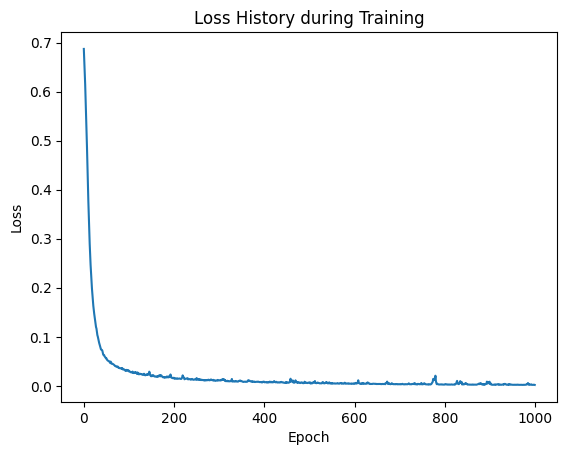

In [ ]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss History during Training')
plt.show()

In [ ]:
with torch.no_grad():
  outputs = model(X_tensor)
  predicted = (torch.sigmoid(outputs) > 0.5).float()
  accuracy = (predicted == y_tensor).sum().item() / len(y_tensor)
  print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


## Reflection Questions

1. **Computational graphs.** PyTorch uses *dynamic* computational graphs (defined at runtime) while TensorFlow 1.x used *static* graphs (defined before execution). What are the practical advantages of dynamic graphs for debugging and research?

2. **`optimizer.zero_grad()`.** Why must we call `optimizer.zero_grad()` at the start of every mini-batch? What would happen if we omitted it?

3. **Adding depth.** How would you modify the `nn.Module` below to add a third hidden layer of size 8? What other changes would you need to make to `forward()`?

4. **SGD vs Adam.** SGD with momentum uses $v_t = \mu v_{t-1} + g_t$ and $\theta \leftarrow \theta - \alpha v_t$. Adam additionally normalises by the second moment $v_t$. When might plain SGD generalise *better* than Adam despite converging slower?

## Answers

**1. Dynamic vs static graphs.**
Dynamic graphs let you use standard Python control flow (`if`, `for`, `while`) inside `forward()`, making debugging with `print` and `pdb` natural. Static graphs require special control flow ops and compile the full graph before any data is seen. Dynamic graphs also simplify variable-length sequences and conditional architectures like tree-structured models.

**2. `zero_grad()`.**
PyTorch *accumulates* gradients in `.grad` by default (useful for gradient accumulation tricks). Without zeroing, gradients from previous batches add to the current batch's gradients, effectively computing a weighted sum over all past batches — leading to incorrect and diverging updates.

**3. Adding a third hidden layer.**
Add `self.fc3 = nn.Linear(hidden_size, 8)` and `self.fc4 = nn.Linear(8, output_size)` in `__init__`, and chain them in `forward`: `x = torch.sigmoid(self.fc3(x)); x = self.fc4(x)`. Alternatively, use `nn.Sequential`.

**4. SGD vs Adam.**
Adam's adaptive learning rates allow it to find sharp minima that happen to have low training loss but poor generalisation. SGD with momentum tends to find flatter minima that generalise better on held-out data. This has been empirically observed on image classification benchmarks (Wilson et al., 2017).